<a href="https://colab.research.google.com/github/Jothini-Venkidusamy/Jothini-Codebooster-2026/blob/main/Day5/Weather_Intelligent_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
from datetime import datetime
import sqlite3
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [ ]:
API_KEY = '9b5026518f01053bd2b3128aeb47214c'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad','Kolkata','Pune','Jaipur']

print(f'API Configured for {len(CITIES)} CITIES')
print(f'Cities: {CITIES}')


API Configured for 8 CITIES
Cities: ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [ ]:
weather_data = []

for city in CITIES:
    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    response = requests.get(BASE_URL, params=params)
    data = response.json()

    weather_data.append({
        'City': city,
        'Temperature': data['main']['temp'],
        'Feels_Like': data['main']['feels_like'],
        'Humidity': data['main']['humidity'],
        'Pressure': data['main']['pressure'],
        'Wind_Speed': data['wind']['speed'],
        'Weather': data['weather'][0]['main'],
        'Description': data['weather'][0]['description'],
        'Date_Time': datetime.now()
    })

print("Weather data collected successfully!")

Weather data collected successfully!


In [ ]:
weather_df = pd.DataFrame(weather_data)
print(weather_df)

        City  Temperature  Feels_Like  Humidity  Pressure  Wind_Speed Weather  \
0     Mumbai        33.99       40.99        59      1008        5.14   Smoke   
1      Delhi        35.05       36.17        36      1005        5.66   Clear   
2  Bangalore        31.20       34.28        56      1008        7.60  Clouds   
3    Chennai        34.15       41.15        60      1006        4.12  Clouds   
4  Hyderabad        37.23       37.55        28      1005        8.23  Clouds   
5    Kolkata        33.97       40.97        62      1003        3.09    Haze   
6       Pune        35.22       34.58        28      1007        6.20   Clear   
7     Jaipur        34.62       33.94        29       999        3.60    Haze   

        Description                  Date_Time  
0             smoke 2026-05-30 09:05:45.401070  
1         clear sky 2026-05-30 09:05:45.512027  
2  scattered clouds 2026-05-30 09:05:45.596373  
3  scattered clouds 2026-05-30 09:05:45.684134  
4  scattered clouds 2026-

In [ ]:
weather_df.head()

,City,Temperature,Feels_Like,Humidity,Pressure,Wind_Speed,Weather,Description,Date_Time
0,Mumbai,33.99,40.99,59,1008,5.14,Smoke,smoke,2026-05-30 09:05:45.401070
1,Delhi,35.05,36.17,36,1005,5.66,Clear,clear sky,2026-05-30 09:05:45.512027
2,Bangalore,31.20,34.28,56,1008,7.60,Clouds,scattered clouds,2026-05-30 09:05:45.596373
3,Chennai,34.15,41.15,60,1006,4.12,Clouds,scattered clouds,2026-05-30 09:05:45.684134
4,Hyderabad,37.23,37.55,28,1005,8.23,Clouds,scattered clouds,2026-05-30 09:05:45.763758


In [ ]:
weather_df.to_csv('weather_raw_data.csv', index=False)

print("Raw dataset saved successfully!")

Raw dataset saved successfully!


In [ ]:
print("Dataset Shape:", weather_df.shape)

Dataset Shape: (8, 9)


In [ ]:
print('Missing Values: ')
weather_df.isnull().sum()

Missing Values: 


,0
City,0
Temperature,0
Feels_Like,0
Humidity,0
Pressure,0
Wind_Speed,0
Weather,0
Description,0
Date_Time,0


In [ ]:
print("Duplicate Rows:", weather_df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
conn = sqlite3.connect("weather.db")
cursor = conn.cursor()
print("Database 'weather.db' created successfully")
print(f"Table 'weather_data' has {len(weather_df)} rows")

Database 'weather.db' created successfully
Table 'weather_data' has 8 rows


In [ ]:
weather_df.to_sql(
    'weather_data',
    conn,
    if_exists='replace',
    index=False
)

print("Table created successfully!")

Table created successfully!


In [ ]:
def run_query(sql, description="weather_data"):
    if description:
        print(f"\n{'=' * 55}")
        print(f"{description}")
        print(f"{'=' * 55}")

    result = pd.read_sql_query(sql, conn)
    return result

print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_label)")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_label)


In [ ]:
query1="""
  SELECT * FROM weather_data
"""
result1 = run_query(query1, "All Weather Data")
print(result1)


All Weather Data
        City  Temperature  Feels_Like  Humidity  Pressure  Wind_Speed Weather  \
0     Mumbai        33.99       40.99        59      1008        5.14   Smoke   
1      Delhi        35.05       36.17        36      1005        5.66   Clear   
2  Bangalore        31.20       34.28        56      1008        7.60  Clouds   
3    Chennai        34.15       41.15        60      1006        4.12  Clouds   
4  Hyderabad        37.23       37.55        28      1005        8.23  Clouds   
5    Kolkata        33.97       40.97        62      1003        3.09    Haze   
6       Pune        35.22       34.58        28      1007        6.20   Clear   
7     Jaipur        34.62       33.94        29       999        3.60    Haze   

        Description                   Date_Time  
0             smoke  2026-05-30 09:05:45.401070  
1         clear sky  2026-05-30 09:05:45.512027  
2  scattered clouds  2026-05-30 09:05:45.596373  
3  scattered clouds  2026-05-30 09:05:45.684134  
4 

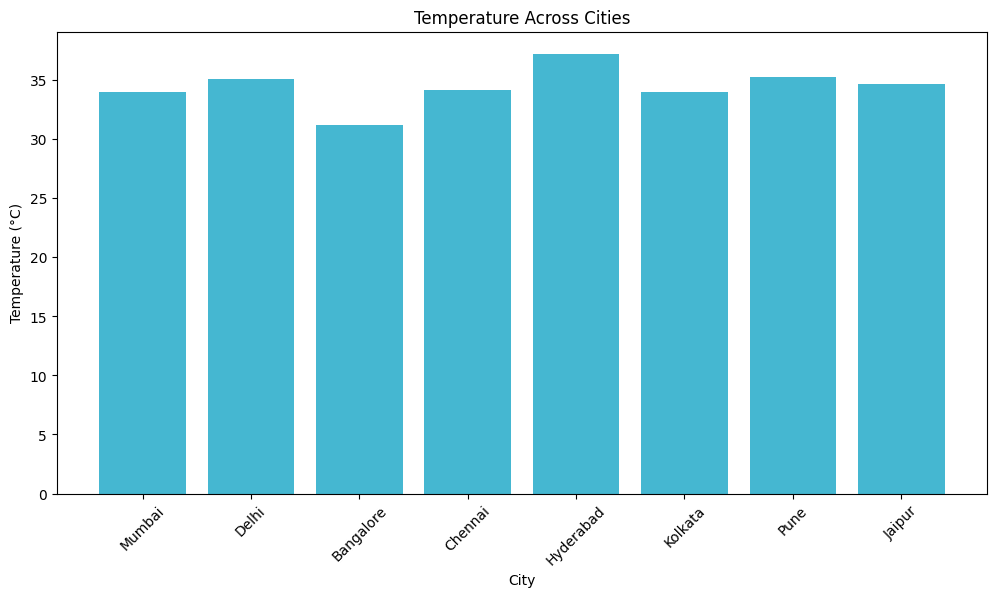

In [ ]:
plt.figure(figsize=(12,6))

colors = ['#45B7D1']

plt.bar(
    weather_df['City'],
    weather_df['Temperature'],
    color=colors
)

plt.title('Temperature Across Cities')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=45)

plt.show()

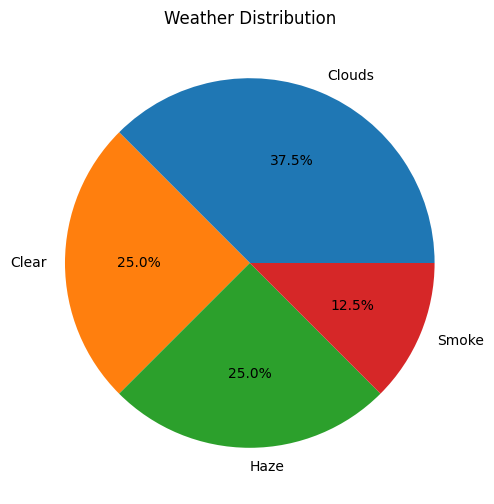

In [ ]:
plt.figure(figsize=(6,6))

weather_df['Weather'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Weather Distribution')
plt.ylabel('')

plt.show()